Questo è il Notebook relativo alla task 4 del progetto.

In [95]:
# Librerie
import numpy as np
from scipy.sparse import csc_matrix, coo_matrix
from scipy.sparse.linalg import spsolve_triangular
from sksparse.cholmod import cholesky
import time
import gc
from sksparse.cholmod import cholesky, CholmodOutOfMemoryError

# Funzione che legge le matrici in formato COO e restituisce la matrice in formato CSC
def read_coo_to_csc(a_filename):
    data_A = np.loadtxt(a_filename)
    rows = data_A[:, 0].astype(int)
    cols = data_A[:, 1].astype(int)
    vals = data_A[:, 2]
    A_coo = coo_matrix((vals, (rows, cols)))
    return A_coo.tocsc()

# Funzione che legge il termine noto b
def read_rhs(rhs_filename):
    return np.loadtxt(rhs_filename)

# Funzione che calcola la fattorizzazione di Cholesky di una matrice
def my_cholesky(A):
    try:
        factor = cholesky(A, order="natural")
    except TypeError:
        factor = cholesky(A, ordering_method="natural")
    # 'factor' e' una TUPLA: factor[0] e' il fattore superiore R (A = R^T R)
    R = csc_matrix(factor[0])
    return R.T.tocsc()  # restituisce la matrice triangolare inferiore L in formato CSC

# Funzione che risolve il sistema lineare Au = b usando la fattorizzazione di Cholesky
def solve_cholesky(L, b):
    y = spsolve_triangular(L, b, lower=True)            # Risolvo L y = b
    u = spsolve_triangular(L.T.tocsc(), y, lower=False)  # Risolvo L^T u = y
    return u

#definisco una nuova funzione che fattorizza e risolve misurando i tempo MA che restituisce None se la memoria non è sufficiente
def cholesky_and_solve(A, b):
    try: 
        t0 = time.perf_counter()
        L = my_cholesky(A)
        t_fact = time.perf_counter() - t0
      

        t0 = time.perf_counter()
        u = solve_cholesky(L, b)
        t_solve = time.perf_counter() - t0

    except (CholmodOutOfMemoryError):
            gc.collect()
            return None 

    nnz_L = L.nnz
    del L
    gc.collect()
    return u, nnz_L, t_fact, t_solve

       

# --- Lettura dei dati ---
A_orig_CSC = read_coo_to_csc("A_orig.txt")
A_reordered_CSC = read_coo_to_csc("A_reordered.txt")

print("=== MATRICE ORIGINALE ===")
print(f"Dimensione : {A_orig_CSC.shape}")  # dimensione della matrice n x m
print(f"NNZ        : {A_orig_CSC.nnz}\n")  # numero di elementi non nulli

print("=== MATRICE RIORDINATA ===")
print(f"Dimensione : {A_reordered_CSC.shape}")
print(f"NNZ        : {A_reordered_CSC.nnz}\n")

# Cambio segno ad A e b: (-A) u = (-b) ha la stessa soluzione, con matrice definita positiva
A_orig = -A_orig_CSC
A_reordered = -A_reordered_CSC
b_orig = -read_rhs("rhs_orig.txt")
b_reordered = -read_rhs("rhs_reordered.txt")

#Risoluzione
res_orig = cholesky_and_solve(A_orig, b_orig)
res_reord = cholesky_and_solve(A_reordered, b_reordered)

# --- Stampa dei risultati ---

print("=== SISTEMA ORIGINALE ===")
if res_orig is None:
    print("Memoria esaurita: fattorizzazione non eseguibile con l'ordinamento naturale\n")
else:
    u_orig, nnz_orig, tf_orig, ts_orig = res_orig
    print(f"Fill-in NNZ(L)   : {nnz_orig}\n")

print("=== SISTEMA RIORDINATO ===")
if res_reord is None:
    print("Memoria esaurita anche con il riordinamento\n")
else:
    u_reord, nnz_reord, tf_reord, ts_reord = res_reord
    print(f"Fill-in NNZ(L)   : {nnz_reord}\n")

# ATTENZIONE: u_orig e u_reord contengono gli stessi valori in ordine diverso (N^2 elementi in totale)
if res_orig is not None:
    print("Primi 10 elementi della soluzione:", u_orig[:10])
if res_reord is not None:
    print("Primi 10 elementi della soluzione riordinata:", u_reord[:10])

print("\n=== PRESTAZIONI (TEMPI IN SECONDI) ===")
if res_orig is not None:
    print(f"Originale  -> Fattorizzazione: {tf_orig:.6f} s | Soluzione: {ts_orig:.6f} s | Totale: {tf_orig + ts_orig:.6f} s")
if res_reord is not None:
    print(f"Riordinato -> Fattorizzazione: {tf_reord:.6f} s | Soluzione: {ts_reord:.6f} s | Totale: {tf_reord + ts_reord:.6f} s")
if res_orig is not None and res_reord is not None:
    print(f"Speedup Fattorizzazione: {tf_orig / tf_reord:.2f}x")


=== MATRICE ORIGINALE ===
Dimensione : (1024, 1024)
NNZ        : 4992

=== MATRICE RIORDINATA ===
Dimensione : (1024, 1024)
NNZ        : 4992

=== SISTEMA ORIGINALE ===
Fill-in NNZ(L)   : 32799

=== SISTEMA RIORDINATO ===
Fill-in NNZ(L)   : 15968

Primi 10 elementi della soluzione: [0.11069275 0.17630735 0.21512202 0.23596293 0.24394433 0.24250344
 0.23420241 0.22107105 0.20476151 0.18662177]
Primi 10 elementi della soluzione riordinata: [0.11069275 0.17630735 0.17630735 0.29170809 0.23596293 0.40622997
 0.21512202 0.36444714 0.23596293 0.40622997]

=== PRESTAZIONI (TEMPI IN SECONDI) ===
Originale  -> Fattorizzazione: 0.002830 s | Soluzione: 0.005508 s | Totale: 0.008338 s
Riordinato -> Fattorizzazione: 0.003352 s | Soluzione: 0.002104 s | Totale: 0.005456 s
Speedup Fattorizzazione: 0.84x


# Task 5 — Confronto tra ordinamento naturale e nested dissection

Abbiamo risolto $-A\,u = -b$ per $N = 32, 64, \dots, 1024$ (cioè $N^2$ incognite) con la fattorizzazione di Cholesky $-A = LL^T$,
una volta con l'ordinamento naturale di `coords.txt` e una volta con l'ordinamento di `ordering.txt` (nested dissection).
Per ogni $N$ abbiamo confrontato il numero di elementi non nulli di $L$ (fill-in) e i tempi di fattorizzazione e di soluzione.
Generiamo poi i grafici delle soluzioni e delle immagini delle strutture della matrici con e senza riordinamento della nested-dissection.

Differenza relativa tra u_orig e u_reord_restored: 1.70e-14


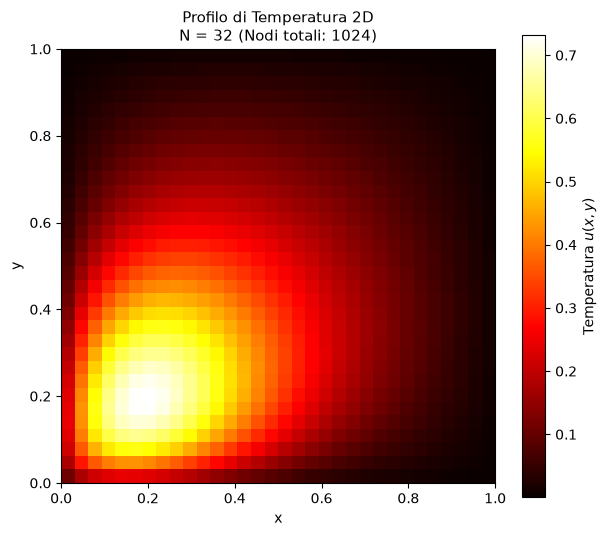

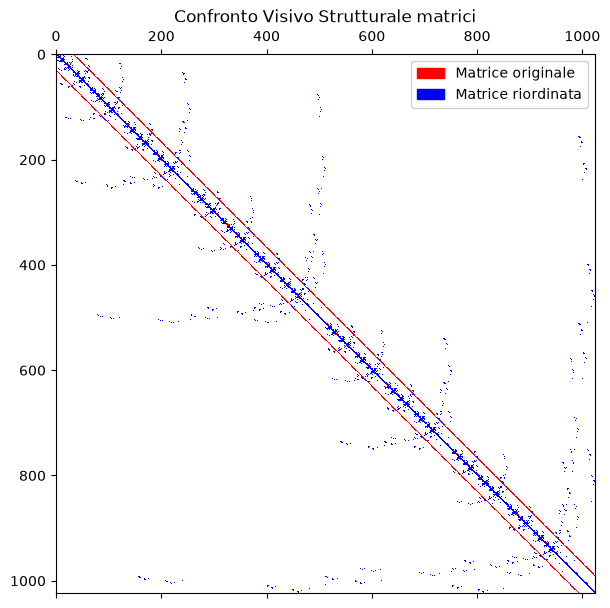

In [96]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches


def plot_solution_2d(u, N=None, title="Profilo di Temperatura 2D"):
    # Se N non viene fornito esplicitamente, lo calcoliamo dalla lunghezza del vettore u
    if N is None:
        N = int(np.sqrt(len(u)))

    nodi_totali = N * N

    # Reshape del vettore 1D nella griglia 2D NxN
    U_grid = u.reshape((N, N), order="F") # in questo modo, la griglia viene riempita colonna per colonna, che è coerente con l'ordine di memorizzazione dei dati .

    plt.figure(figsize=(7, 6))

    # Mappa di calore 2D (imshow)
    im = plt.imshow(U_grid, cmap="hot", origin="lower", extent=[0, 1, 0, 1])

    plt.colorbar(im, label="Temperatura $u(x,y)$")

    # Titolo con Profilo di Temperatura 2D, N e Nodi Totali
    plt.title(
        f"{title}\nN = {N} (Nodi totali: {nodi_totali})",
        fontsize=11,
    )

    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(False)
    plt.show()


#voglio riportare u_ord nell'ordine originale
#Caricamento del file di permutazione (colonna 0: m, colonna 1: n)
ordering = np.loadtxt("ordering.txt").astype(int)
m_indices = ordering[:, 0]  # Indici nel sistema riordinato
n_indices = ordering[:, 1]  # Indici nel sistema originale

#Inizializzazione del vettore ripristinato
if res_reord is not None:
     u_reord_restored = np.zeros_like(u_reord)


# Mappatura diretta: l'elemento in posizione m va nella posizione originale n
u_reord_restored[n_indices] = u_reord[m_indices]

#Verifica della coincidenza tra la soluzione originale e quella ripristinata
if res_orig is not None:
       diff = np.linalg.norm(u_orig - u_reord_restored) / np.linalg.norm(u_orig)
       print(f"Differenza relativa tra u_orig e u_reord_restored: {diff:.2e}") 



#plot per il sistema orginale se u_orig è sato prodotto altrimento con il sistema riordinato
if res_orig is not None:
    
    plot_solution_2d(u_orig, title="Profilo di Temperatura 2D")
    
else:
    
    plot_solution_2d(u_reord_restored, title="Profilo di Temperatura 2D")
    
#creazione immagini struttura della marice

plt.figure(figsize=(7, 7))

# Grafico della prima matrice in rosso (quadrati)
plt.spy(A_orig, color='red', marker=',', label='Elementi matrice originale')

# Sovrapposizione della seconda matrice in blu (cerchi)
plt.spy(A_reordered, color='blue', marker=',', label='Elementi matrice riordinata')

plt.title("Confronto Visivo Strutturale matrici")
legend_elements = [
    mpatches.Patch(color='red', label='Matrice originale'),
    mpatches.Patch(color='blue', label='Matrice riordinata')
]

plt.legend(handles=legend_elements, framealpha=0.9)
plt.show()




# Task 5 — Grafici soluzioni, confronto tempi e entrate non zero e immagini strutture matrici

## N=32

Ancora il numero dei nodi non è molto grande per apprezzare la funzionalità della nested-dissection, ma intanto osserviamo con un po' più di "zoom" rispetto a come vedremo le strutture delle matrici e notiamo come la nested-dissection riorganizzi i punti in varie zone della matrice invece che nelle "linee parallele" che vediamo in rosso. Anche il grafico 2D dei risultati al momento viene un po' a "pixel" a causa del numero basso N.

L'output che viene generato per N=32 è il seguente:

=== MATRICE ORIGINALE ===
Dimensione : (1024, 1024)
NNZ        : 4992

=== MATRICE RIORDINATA ===
Dimensione : (1024, 1024)
NNZ        : 4992

=== SISTEMA ORIGINALE ===
Fill-in NNZ(L)   : 32799

=== SISTEMA RIORDINATO ===
Fill-in NNZ(L)   : 15968

=== PRESTAZIONI (TEMPI IN SECONDI) ===

Originale  -> Fattorizzazione: 0.004392 s | Soluzione: 0.006579 s | Totale: 0.010971 s

Riordinato -> Fattorizzazione: 0.001685 s | Soluzione: 0.001897 s | Totale: 0.003583 s

Speedup Fattorizzazione: 2.61x

I grafici generati, relativi alle temperature e al confronto tra le strutture delle matrici, sono i seguenti:

![grafico 2D](grafico_N_32.png)
![Confronto matrici](matrici_N_32.png)

## N=64

Anche in questo caso nonostante possiamo vedere che il NNZ della matrice triangolare L sia ridotto di circa un terzo il tempo che impiega a fattorizzare e a risolvere è molto breve in entrambi i casi, perchè il numero N è ancora abbastanza piccolo.

L'output che viene generato per N=64 è il seguente:

=== MATRICE ORIGINALE ===
Dimensione : (4096, 4096)
NNZ        : 20224

=== MATRICE RIORDINATA ===
Dimensione : (4096, 4096)
NNZ        : 20224

=== SISTEMA ORIGINALE ===
Fill-in NNZ(L)   : 262207

=== SISTEMA RIORDINATO ===
Fill-in NNZ(L)   : 88554

=== PRESTAZIONI (TEMPI IN SECONDI) ===

Originale  -> Fattorizzazione: 0.020983 s | Soluzione: 0.062215 s | Totale: 0.083198 s

Riordinato -> Fattorizzazione: 0.047999 s | Soluzione: 0.020463 s | Totale: 0.068462 s

Speedup Fattorizzazione: 0.44x

I grafici generati, relativi alle temperature e al confronto tra le strutture delle matrici, sono i seguenti:

![grafico 2D](grafico_N_64.png)
![Confronto matrici](matrici_N_64.png)

## N=128

L'output che viene generato per N=128 è il seguente:

=== MATRICE ORIGINALE ===
Dimensione : (16384, 16384)
NNZ        : 81408

=== MATRICE RIORDINATA ===
Dimensione : (16384, 16384)
NNZ        : 81408

=== SISTEMA ORIGINALE ===
Fill-in NNZ(L)   : 2097279

=== SISTEMA RIORDINATO ===
Fill-in NNZ(L)   : 463476

=== PRESTAZIONI (TEMPI IN SECONDI) ===

Originale  -> Fattorizzazione: 0.120457 s | Soluzione: 0.170887 s | Totale: 0.291344 s

Riordinato -> Fattorizzazione: 0.037224 s | Soluzione: 0.039733 s | Totale: 0.076957 s

Speedup Fattorizzazione: 3.24x

I grafici generati, relativi alle temperature e al confronto tra le strutture delle matrici, sono i seguenti:

![grafico 2D](grafico_N_128.png)
![Confronto matrici](matrici_N_128.png)

## N=256

In questo caso si inizia ad osservare l'importanza del riordinamento con la nested-dissection: il numero dei non zeri è circa 7 volte più piccolo per la matrice L ottenuta con A riordinata e il tempo di fattorizzazione e di risoluzione risulta circa 10 volte più piccolo.

L'output che viene generato per N=256 è il seguente:

=== MATRICE ORIGINALE ===
Dimensione : (65536, 65536)
NNZ        : 326656

=== MATRICE RIORDINATA ===
Dimensione : (65536, 65536)
NNZ        : 326656

=== SISTEMA ORIGINALE ===
Fill-in NNZ(L)   : 16777471

=== SISTEMA RIORDINATO ===
Fill-in NNZ(L)   : 2318974

=== PRESTAZIONI (TEMPI IN SECONDI) ===

Originale  -> Fattorizzazione: 1.039032 s | Soluzione: 1.343505 s | Totale: 2.382537 s

Riordinato -> Fattorizzazione: 0.161105 s | Soluzione: 0.189230 s | Totale: 0.350335 s

Speedup Fattorizzazione: 6.45x

I grafici generati, relativi alle temperature e al confronto tra le strutture delle matrici, sono i seguenti:

![grafico 2D](grafico_N_256.png)
![Confronto matrici](matrici_N_256.png)

## N=512

Per N=512 è ancora possibile avere entrambe le soluzioni e e questo è il caso in cui si può apprezzare con maggiore rilevanza la differenze dei tempi di fattorizzazione e risoluzione del sistema tra i dati originali e quelli riorganizzati con la nested-dissection. L'output è il seguente:

=== MATRICE ORIGINALE ===
Dimensione : (262144, 262144)
NNZ        : 1308672

=== MATRICE RIORDINATA ===
Dimensione : (262144, 262144)
NNZ        : 1308672

=== SISTEMA ORIGINALE ===
Fill-in NNZ(L)   : 134218239

=== SISTEMA RIORDINATO ===
Fill-in NNZ(L)   : 11206792

=== PRESTAZIONI (TEMPI IN SECONDI) ===

Originale  -> Fattorizzazione: 22.185818 s | Soluzione: 12.161307 s | Totale: 34.347125 s

Riordinato -> Fattorizzazione: 1.031823 s | Soluzione: 0.872506 s | Totale: 1.904328 s

Speedup Fattorizzazione: 21.50x

I grafici generati sono i seguenti:

![grafico 2D](grafico_N_512.png)
![Confronto matrici](matrici_N_512.png)


## N=1024

Per N=1024 viene stampata solamente la soluzione del sistema riordinato in quanto quello con ordinamento originale occupa troppo spazio nella memoria RAM: con questi numeri di nodi si vedono quindi a pieno le potenzialità della nested-dissection, che ci permette di fare un operazione che altrimenti sarebbe risultata impossibile. Questo l'uotput che viene stampato:

=== MATRICE ORIGINALE ===
Dimensione : (1048576, 1048576)
NNZ        : 5238784

=== MATRICE RIORDINATA ===
Dimensione : (1048576, 1048576)
NNZ        : 5238784

=== SISTEMA ORIGINALE ===
Memoria esaurita: fattorizzazione non eseguibile con l'ordinamento naturale

=== SISTEMA RIORDINATO ===
Fill-in NNZ(L)   : 52721810

=== PRESTAZIONI (TEMPI IN SECONDI) ===
Riordinato -> Fattorizzazione: 4.830336 s | Soluzione: 4.310232 s | Totale: 9.140568 s

I grafici generati sono i seguenti:

![grafico 2D](grafico_N_1024.png)
![Confronto matrici](matrici_N_1024.png)




